In [103]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split, KFold

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian, decimate
from evaluation.calc_stats import * 
from scipy.stats import pearsonr 

%matplotlib inline

### Load spikes and neuromodulation signal

In [104]:
data_dir = '../../data/recordings/nk341_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_669, 7_869
bin_size = 0.05
bs = 256 # batch size 

convolve_spikes = True  
z_score = False 
center = False 

In [105]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'electrophysiology')
    files = [f for f in os.listdir(spikes_dir) if os.path.isfile(os.path.join(spikes_dir, f))]
    files = sorted(files)
    t_start, t_end = 10, 0
    for f in files:
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))

    # remove twenty seconds in the end  
    t_end = t_end - 20
    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    whisking_dir = os.path.join(data_dir, 'physiology')

    lc_neuromod_deconv = pd.read_csv(f'{neuromod_dir}/norepinephrine_deconvolved.csv', header=None).to_numpy().flatten()
    lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine_full.csv', header=None).to_numpy().flatten()
    whisking = pd.read_csv(f'{whisking_dir}/whisking.csv', header=None).to_numpy().flatten()

    # Downsampling parameters
    fs, target_fs = 1000, 1 / bin_size  # Target sampling rate (20 Hz)
    downsample_factor = int(fs / target_fs)  # Compute downsample factor

    # Downsample using scipy.signal.decimate (handles anti-aliasing)
    downsampled_signal = decimate(lc_neuromod, downsample_factor, ftype='fir', zero_phase=True)
    print(f'length of downsampled signal: {len(downsampled_signal)}')
    print(f'length of original signal: {len(lc_neuromod)}')
    lc_neuromod = downsampled_signal
    
    # select within chosen window 
    lc_neuromod = lc_neuromod[int(t_start / bin_size):int(t_end / bin_size)]
    lc_neuromod_deconv = lc_neuromod_deconv[int(t_start / bin_size):int(t_end / bin_size)]
    whisking = whisking[int(t_start / bin_size):int(t_end / bin_size)]

    # replace nans with zero 
    lc_neuromod = np.nan_to_num(lc_neuromod)
    
    # center 
    if center:
        lc_neuromod += np.abs(lc_neuromod.min())
    # z-score 
    neuromod_activity_deconv = (lc_neuromod_deconv - lc_neuromod_deconv.mean()) / lc_neuromod_deconv.std()
    if z_score:
        lc_neuromod = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    if convolve_spikes:
        kernel_size = 25 # 100
        sigma = 5 # 10
        # z-score spikes 
        spike_counts = (spike_counts - spike_counts.mean(axis=0)) / (spike_counts.std(axis=0))
        gaussian_kernel = gaussian(kernel_size, sigma) 
        # Make it causal: Zero out future values
        # gaussian_kernel[:kernel_size // 2] = 0
        gaussian_kernel /= gaussian_kernel.sum()
        smoothed_spikes = []
        for n in range(spike_counts.shape[0]):
            smoothed_spikes.append(convolve(spike_counts[n], gaussian_kernel, mode='full'))
        spike_counts = np.array(smoothed_spikes)
        
    # load trials info 
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, lc_neuromod, neuromod_activity_deconv, whisking, trials_df 

In [106]:
spikes, spike_counts, neuromod_activity, neuromod_activity_deconv, whisking, trials_df = load_data()

KeyboardInterrupt: 

In [ ]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

### Split baseline period into training and testing samples and filter out neurons with little activity

In [6]:
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    s_deconv_block = neuromod_activity_deconv[block_start_idx:block_start_idx + block_dur]
    whisking_block = whisking[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block, s_deconv_block, whisking_block

#### Get last 20 minutes block

In [6]:
spike_counts_pt_baseline, s_pt_baseline, s_pt_baseline_deconv, whisking_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
s_pt_baseline = (s_pt_baseline - s_pt_baseline.min()) / (s_pt_baseline.max() - s_pt_baseline.min())


#### Get airpuff blocks

In [ ]:
airpuff_trial_times = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['t'].astype('int').to_list()
airpuff_blocks = [] 
print(airpuff_trial_times)
# for each trial time, get a 20s block of neural and neuromodulatory activity
for t in airpuff_trial_times:
    t_start, t_end = t - 10, t + 10
    # convert to ms
    # t_start, t_end = int(t_start // bin_size), int(t_end // bin_size) 
    airpuff_blocks.append([t_start, t_end])
print(airpuff_blocks)

### Load models

In [245]:
models = {}
neuromodulation = ['None', 'additive', 'postsynaptic', 'presynaptic', 'rank']
filters = ['_50ms_zsc_conv_2000']

for neuromod in neuromodulation:
    for fold in range(1, 11):
        for filter in filters:
            # if neuromod == 'None' and filter != '': continue 
            # except outliers
            # if neuromod == 'None' and fold == 1: continue 
            # if neuromod == 'additive' and filter == '' and fold == 8: continue
            # if neuromod == 'postsynaptic' _fold_{fold}{filter}
            try:
                vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_{neuromod}_rank_4_231_gauss_fold_{fold}{filter}')
                models[(neuromod+filter, fold)] = vae
            except: 
                print(f'Not found: {neuromod, fold, filter}')            

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\recordings\../..\vi_rnn\saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using clipped ReLU activation
using uniform init
weight scaler 1
Not found: ('None', 2, '_50ms_zsc_conv_2000')
Not found: ('None', 3, '_50ms_zsc_conv_2000')
Not found: ('None', 4, '_50ms_zsc_conv_2000')
Not found: ('None', 5, '_50ms_zsc_conv_2000')
Not found: ('None', 6, '_50ms_zsc_conv_2000')
Not found: ('None', 7, '_50ms_zsc_conv_2000')
Not found: ('None', 8, '_50ms_zsc_conv_2000')
Not found: ('None', 9, '_50ms_zsc_conv_2000')
Not found: ('None', 10, '_50ms_zsc_conv_2000')
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: additive
using clipped ReLU activation
using uniform init
weight scaler 1
Not found: ('additive', 2, '_50ms_zsc_conv_2000')
Not found: ('additive', 3, '_50ms_zsc_conv_2000')
Not found: ('additive', 4, '_50ms_zsc_conv_20

In [246]:
models.keys()

dict_keys([('None_50ms_zsc_conv_2000', 1), ('additive_50ms_zsc_conv_2000', 1), ('postsynaptic_50ms_zsc_conv_2000', 1), ('presynaptic_50ms_zsc_conv_2000', 1), ('rank_50ms_zsc_conv_2000', 1)])

### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [46]:
def get_trajectory(t_start, t_end, vae, neuromod):
    """
    Args:
        t_start (int): bin index in which to start the trajectory
        t_end (int): bin index in which to end the trajectory 
        vae (VAE): the model 
        neuromod: the neuromodulation type
    Returns:
        obs (torch.tensor; num_neurons x T): Generated trajectory
    """
    spike_counts_val, neuromod_val, neuromod_activity_deconv_val, whisking_val = get_block(spike_counts, neuromod_activity, t_start, t_end)
    T = neuromod_val.shape[0]
    spike_counts_val = torch.from_numpy(spike_counts_val).to(torch.float32)
    z_hat, _, _, _ = vae.encoder(spike_counts_val.unsqueeze(0))
    z0 = z_hat[:, :, 0].squeeze()
    s_test_block = None 
    if 'deconv' in neuromod:
        s_test_block = torch.from_numpy(neuromod_activity_deconv_val).to(torch.float32).view(1, 1, -1)
    elif 'whisking' in neuromod:
        s_test_block = torch.from_numpy(whisking_val).to(torch.float32).view(1, 1, -1)
    elif 'None' not in neuromod:
        s_test_block = torch.from_numpy(neuromod_val).to(torch.float32).view(1, 1, -1)
        s_test_block = (s_test_block - s_test_block.min()) / (s_test_block.max() - s_test_block.min()) 
    if 'additive' in neuromod:
        Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s=True)
        obs = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
    else: 
        Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s = False)
        obs = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]
    return obs 

In [18]:
def get_stats(vae, neuromod, seq_periods_eval, num_trajs=10,):
    kl_divs, lls, mres, pshs, pairwise_corrs = [], [], [], [], []
    data = torch.from_numpy(spike_counts_pt_baseline).to(torch.float32)
    for block in seq_periods_eval:
        block_start = block[0] 
        block_end = block[1] 
        # data[:, block_start:block_end] = (data[:, block_start:block_end] - data[:, block_start:block_end].mean(axis=0)) / (data[:, block_start:block_end].std(axis=0))
        T = block_end - block_start 
        z_hat, _, _, _ = vae.encoder(data[:, block_start:block_end].unsqueeze(0))
        print(z_hat.shape)
        z0 = z_hat[:, :, 0].squeeze() 
        sim_s, s_test_block = False, None 
        kl_div_arr, mr_arr, pairwise_corr_arr, psh_arr = [], [], [], []
        if 'deconv' in neuromod:
            s_test_block = torch.from_numpy(neuromod_activity_deconv[block_start:block_end]).to(torch.float32).view(1, 1, -1)
        elif 'whisking' in neuromod:
            s_test_block = torch.from_numpy(whisking[block_start:block_end]).to(torch.float32).view(1, 1, -1)
        elif 'None' not in neuromod:
            # s_test_block = torch.from_numpy(neuromod_activity[block_start:block_end]).to(torch.float32).view(1, 1, -1)
            s_test_block = torch.from_numpy(s_pt_baseline[block_start:block_end]).to(torch.float32).view(1, 1, -1)
        print(f's_test = {s_test_block}')
        for _ in range(num_trajs):
            if 'additive' in neuromod:
                Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s=True)
                out = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
            else: 
                Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s = False)
                out = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]

            if out_likelihood == 'Poisson':
                out = torch.poisson(out).T.detach()
            fig, ax = plt.subplots(6, 10, figsize=(15, 15))
            idx_i, idx_j = 0, 0
            for i in range(60):
                ax[idx_i, idx_j].plot(data[i, block_start:block_end], label=f'Neural activity')
                ax[idx_i, idx_j].plot(out[i, :].detach(), label=f'Predicted Neural activity')
                idx_j += 1
                if idx_j >= 10: 
                    idx_i, idx_j = idx_i + 1, 0
            fig.suptitle(f'{neuromod}, {block_start}-{block_end}')
            if ret == 'traj': return out 
            kl_div = compute_KL_divergence(out.unsqueeze(0), data[:, block_start:block_end].unsqueeze(0))
            mr = mean_rate(out.detach().numpy(), data[:, block_start:block_end].numpy())
            psh = power_spectrum_helling(out.unsqueeze(0).detach().numpy(), data[:, block_start:block_end].unsqueeze(0).numpy(), smoothing=10, freq_cutoff=10000) 
            corr_gen = calculate_correlation(out.detach().T.numpy())
            corr_test = calculate_correlation(data[:, block_start:block_end].T.numpy())
            nas = np.logical_or(np.isnan(corr_gen), np.isnan(corr_test))
            pairwise_corr = pearsonr(corr_gen[~nas].flatten(), corr_test[~nas].flatten()) 

            kl_div_arr.append(kl_div)
            mr_arr.append(mr)
            pairwise_corr_arr.append(pairwise_corr)
            psh_arr.append(psh)
            
        # if mr > 200:
        #     # if neuromod == 'additive':
            
        _, _, _, _, _, _, ll, _ = vae.forward_Optimal_VGTF(data[:, block_start:block_end].unsqueeze(0), 
                                                   s=s_test_block, 
                                                   sim_s=sim_s, 
                                                   sim_v=False, 
                                                   resample='systematic', 
                                                   u=torch.zeros((1, 0, T)))
        
        kl_div_mean = np.array(kl_div_arr).mean()
        mre_mean = np.array(mr_arr).mean()
        psh_mean = np.array(psh_arr).mean() 
        pairwise_corr_mean = np.array(pairwise_corr_arr).mean() 

        print(neuromod, fold, kl_div_mean, mre_mean, ll, psh_mean, pairwise_corr_mean)

        kl_divs.append(kl_div_mean) 
        mres.append(mre_mean)
        lls.append(ll.item()) 
        pshs.append(psh_mean) 
        pairwise_corrs.append(pairwise_corr_mean)

    return kl_divs, mres, lls, pshs, pairwise_corrs 

In [ ]:
kf = KFold(n_splits=10, shuffle=False)
model_kl_divs = {}
model_mres = {}
model_lls = {}
model_pairwise_corrs = {}
model_pshs = {}

for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    if fold > 1: break
    print(f'Fold: {fold}')
    t_start = int(t_start_post_trial // bin_size)
    # get index of test blocks on spike_counts
    seq_periods_eval = [[test_idx[0], test_idx[-1]]] #+ [block for block in airpuff_blocks]
    # iterate over models and compute stats for current fold 
    for key in models.keys():
        model_name, model_fold = key 
        if model_fold == fold:
            kl_divs, mres, lls, pshs, pairwise_corrs = get_stats(models[key], model_name, seq_periods_eval, key[1], num_trajs=10)
            if key[0] not in model_lls: 
                model_kl_divs[model_name] = [kl_divs]
                model_lls[model_name] = [lls]
                model_mres[model_name] = [mres]
                model_pairwise_corrs[model_name] = [pairwise_corrs]
                model_pshs[model_name] = [pshs]
            else:
                model_kl_divs[model_name].append(kl_divs)
                model_lls[model_name].append(lls)
                model_mres[model_name].append(mres)
                model_pairwise_corrs[model_name].append(pairwise_corrs)
                model_pshs[model_name].append(pshs)

for key in model_kl_divs.keys():
    model_kl_divs[key] = np.array(model_kl_divs[key])
    model_lls[key] = np.array(model_lls[key])
    model_mres[key] = np.array(model_mres[key])
    model_pairwise_corrs[key] = np.array(model_pairwise_corrs[key])
    model_pshs[key] = np.array(model_pshs[key])

### Remove outliers

In [18]:
model_mres['postsynaptic'] = np.delete(model_mres['postsynaptic'], 5, axis=0)
model_mres['None'] = np.delete(model_mres['None'], 2, axis=0)
model_mres['rank'] = np.delete(model_mres['rank'], 1, axis=0)

In [21]:
def plot_bar(stats: np.array, block_idx: int, title, width=0.4):
    means = [stats[model].mean(axis=0)[block_idx] for model in stats.keys()]
    stds = [stats[model].std(axis=0)[block_idx] for model in stats.keys()] 
    std_err = [stds[i] / len(stats[model]) for i, model in enumerate(stats.keys())]

    x = np.arange(len(means))
    fig, ax = plt.subplots(figsize=(10,8))
    ax.bar(x, means, width, yerr=std_err, alpha=0.7, capsize=5)

    for i, cat in enumerate(stats.keys()):
        x_jittered = x[i] + np.random.uniform(-width/4, width/4, stats[cat].shape[0])
        ax.scatter(x_jittered, stats[cat][:, block_idx], s=10)
    ax.set_xticklabels(list(model_mres.keys()))
    ax.tick_params(axis='both', which='major', labelsize=10)
    ax.set_xticks(x)
    ax.set_title(title, fontsize=15)

def plot_group_bar(stats: np.array, title, width=0.1):
    means = {block: [stats[model].mean(axis=0)[block] for model in stats.keys()] for block in range(3)}
    stds = {block: [stats[model].std(axis=0)[block] for model in stats.keys()] for block in range(3)}
    
    x = np.arange(len(list(means.keys())))
    print(len(x))
    fig, ax = plt.subplots(figsize=(10, 8)) 
    for i, group in enumerate(stats.keys()):
        offsets = x - width / 2 + i * width 
        mean_values = [means[block][i] for block in range(len(list(means.keys())))]
        ax.bar(offsets, mean_values, width, label=group, alpha=0.7)

In [ ]:
model_kl_divs, model_mres, model_pshs

In [ ]:
plot_bar(model_mres, 0, 'Mean-rate error')

In [ ]:
plot_bar(model_kl_divs, 0, 'KL-Divergence')

In [ ]:
plot_bar(model_pshs, 0, 'Hellinger Distance')

In [ ]:
model_set

In [69]:
def plot_raw_traces(tch, num_neurons, num_cols, column_titles, stud, figsize=(6, 6), T=1000):
    num_rows, num_cols = num_neurons, num_cols
    with plt.rc_context({'font.size': 4}):
        fig, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        c = ['r', 'g', 'blue', 'black', 'orange', 'brown']
        column_titles = ["Ground Truth"] + list(column_titles) 
        print(column_titles)
        neurons = np.random.choice(range(0, 94), size=num_neurons, replace=False)
        # Set titles for the top row
        for col, title in enumerate(column_titles):
            ax[0, col].set_title(title, fontsize=12)
        for i, neuron in enumerate(neurons):
            ax[i, 0].plot(tch[neuron, :T], c=c[0])
            ymin, ymax = tch[neuron, :].min(), tch[neuron, :].max()
            for j in range(len(model_set)):
                ax[i, j+1].plot(stud[j][neuron, :T], label=list(model_set)[j], c=c[j+1])
                ymin = min(ymin, stud[j][neuron, :T].min())
                ymax = max(ymax, stud[j][neuron, :T].max())
                # ax[i, j+1].set_yticks([])
            for j in range(0, len(list(model_set)) + 1):
                ax[i, j].set_ylim(ymin, ymax)
                ax[i, j].set_xticks([])
                if j == 0:
                    ax[i, j].set_yticks([round(ymin.item(), 1), round(ymax.item(), 1)])
                ax[i, j].tick_params(axis='both', labelsize=7)
        # plt.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    # fig.savefig('traces.svg', format='svg', bbox_inches='tight')

In [ ]:
kf = KFold(n_splits=10, shuffle=False)
for fold, (train_idx, test_idx) in enumerate(kf.split(s_pt_baseline), start=1):
    if fold != 1: continue 
    t_start = int(t_start_post_trial // bin_size)
    seq_periods_eval = [[t_start + test_idx[0], t_start + test_idx[-1]]] 
    trajs = []
    model_set = set()
    for k in models.keys():
        if k[0] not in model_set:
            print(k)
            model_set.add(k[0])
            traj = get_stats(models[(k[0], fold)], k[0], seq_periods_eval, fold, ret='traj')
            trajs.append(traj.detach())
    
    

#### 2.2. Do qualitative eval

### Compute psth around neuromodulator peaks

In [22]:
t_start_post_trial, spike_counts.shape

(6669, (231, 157204))

In [27]:
def compute_LC_trig_activity(traj, neuromod_val, dur=200): 
    neuromod_zsc = (neuromod_val - neuromod_val.mean()) / neuromod_val.std() 
    # take everything above 2 standard deviations 
    neuromod_peaks = np.where(neuromod_zsc > 2)[0]
    psths_val = np.zeros((len(neuromod_peaks), traj.shape[0], dur))
    nrpn = np.zeros((len(neuromod_peaks), dur))
    for i, peak in enumerate(neuromod_peaks):
        psths_val[i] = traj[:, peak - dur // 2:peak + dur // 2]
        nrpn[i] = neuromod_val[peak - dur // 2:peak + dur // 2]
    psths_val = psths_val.mean(axis=0)
    # sort by time of peak
    max_indices = np.argmax(psths_val, axis=1)
    psths_sorted = psths_val[np.argsort(max_indices)]
    psths_sorted = (psths_sorted - psths_sorted.mean(axis=1, keepdims=True)) / psths_sorted.std(axis=1, keepdims=True)
    nrpn = nrpn.mean(axis=0)
    return psths_val, psths_sorted, nrpn, max_indices

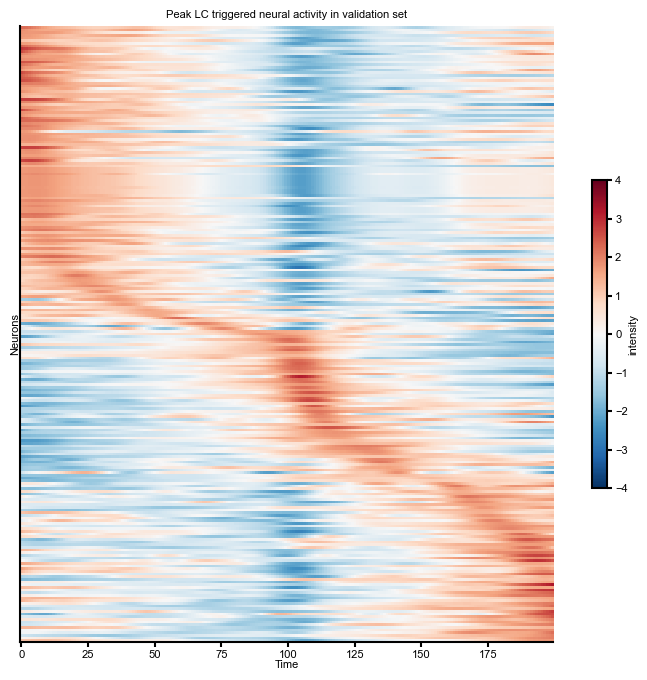

In [247]:
t_start, t_end = t_start_post_trial - 1000, t_start_post_trial
spike_counts_val, neuromod_val, _, _ = get_block(spike_counts, neuromod_activity, t_start, t_end)
_, psths, nrpn, ind = compute_LC_trig_activity(spike_counts_val, neuromod_val)
# partial z_score each row
fig, ax = plt.subplots(figsize=(10, 8))
mappable = ax.imshow(psths, cmap='RdBu_r', vmin=-4, vmax=4)
ax.set_yticks([])
ax.set_yticklabels([])
ax.set_ylabel('Neurons')
ax.set_xlabel('Time')
fig.colorbar(mappable, label='intensity', shrink=0.5)
ax.set_title('Peak LC triggered neural activity in validation set')
plt.show()


None
no input
additive
no input
postsynaptic
no input
presynaptic
no input
rank
no input


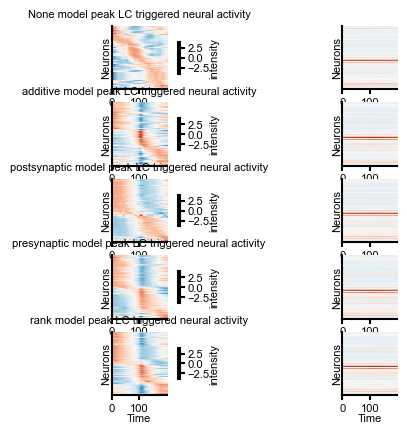

In [281]:
trajs = {}
fig, ax = plt.subplots(len(list(models.keys())), 2)
for i, model in enumerate(models.keys()):
    neuromod = model[0].split('_')[0]
    print(neuromod)
    trajs[neuromod] = get_trajectory(t_start, t_end, models[model], neuromod)
    psth_vals, psths, nrpn, ind_1 = compute_LC_trig_activity(trajs[neuromod].detach(), neuromod_val)
    psths_resorted = psth_vals[np.argsort(ind)]
    mappable1 = ax[i, 0].imshow(psths, cmap='RdBu_r', vmin=-4, vmax=4)
    mappable2 = ax[i, 1].imshow(psths_resorted, cmap='RdBu_r', vmin=-4, vmax=4)

    ax[i, 0].set_yticks([])
    ax[i, 0].set_yticklabels([])
    ax[i, 0].set_ylabel('Neurons')
    ax[i, 0].set_xlabel('Time')

    ax[i, 1].set_yticks([])
    ax[i, 1].set_yticklabels([])
    ax[i, 1].set_ylabel('Neurons')
    ax[i, 1].set_xlabel('Time')

    fig.colorbar(mappable1, label='intensity', shrink=0.5)
    ax[i, 0].set_title(f'{neuromod} model peak LC triggered neural activity')

In [282]:
trajs.keys()

dict_keys(['None', 'additive', 'postsynaptic', 'presynaptic', 'rank'])

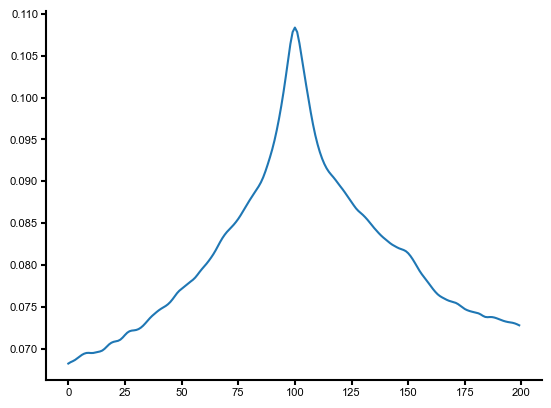

In [283]:
plt.plot(nrpn)

In [284]:
def plot_traces(neurons, traj, spike_counts_block, neuromod_block, neuromod):
    fig, ax = plt.subplots(len(neurons) + 1, 1, figsize=(10, 8))

    for i, neuron in enumerate(neurons): 
        if i == 0:
            ax[i].plot(spike_counts_block[neuron], label='Gen')
            ax[i].plot(traj[neuron].detach(), label='Test')
        else:
            ax[i].plot(spike_counts_block[neuron])
            ax[i].plot(traj[neuron].detach())
        ax[i].set_title(f'R: {pearsonr(spike_counts_block[neuron], traj[neuron].detach())[0]}')
    handles, labels = [], []
    for axis in ax:  # Loop through all axes
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax[-1].plot(neuromod_block)
    ax[-1].set_title('Norepinephrine')
    plt.tight_layout()
    plt.title(f'{neuromod} Traces')
    fig.legend(handles, labels)

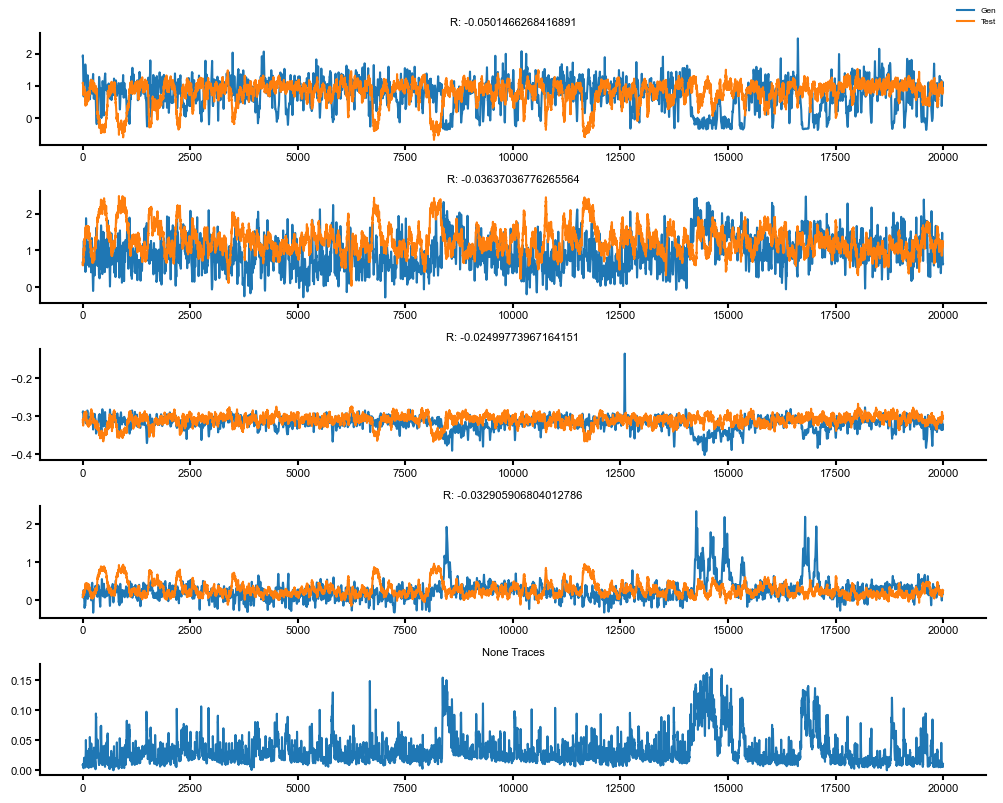

In [285]:
neurons = [172, 50, 15, 167]
plot_traces(neurons, trajs['None'], spike_counts_val, neuromod_val, 'None')

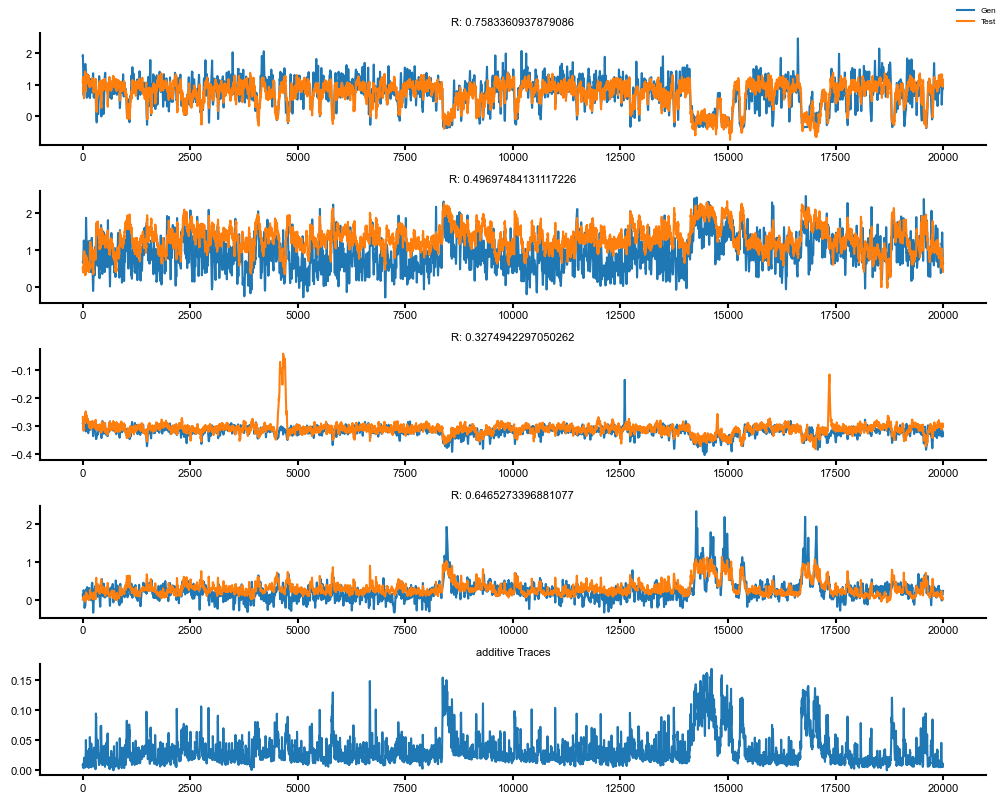

In [286]:
neurons = [172, 50, 15, 167]
plot_traces(neurons, trajs['additive'], spike_counts_val, neuromod_val, 'additive')

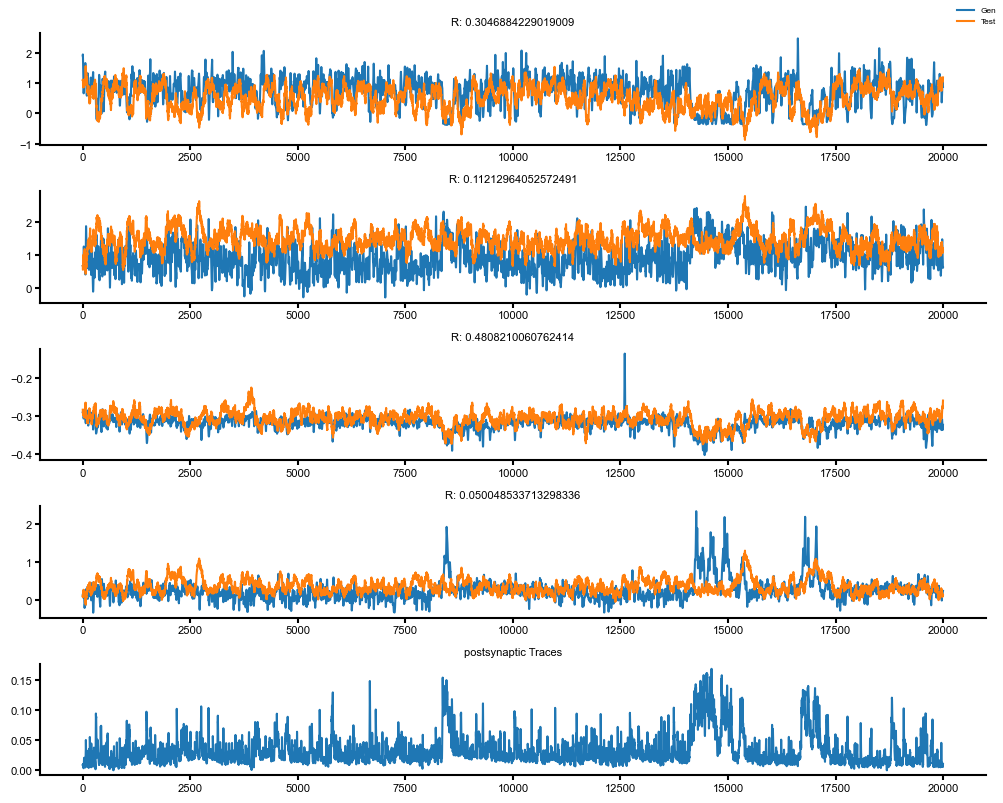

In [287]:
neurons = [172, 50, 15, 167]
plot_traces(neurons, trajs['postsynaptic'], spike_counts_val, neuromod_val, 'postsynaptic')

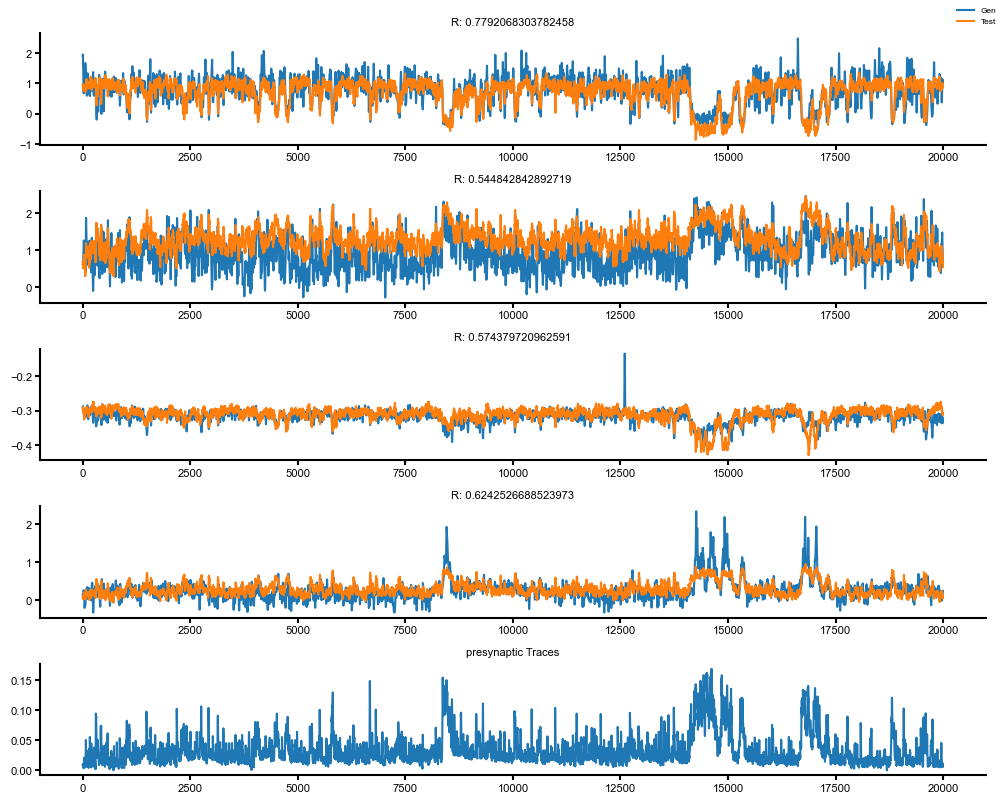

In [288]:
neurons = [172, 50, 15, 167]
plot_traces(neurons, trajs['presynaptic'], spike_counts_val, neuromod_val, 'presynaptic')

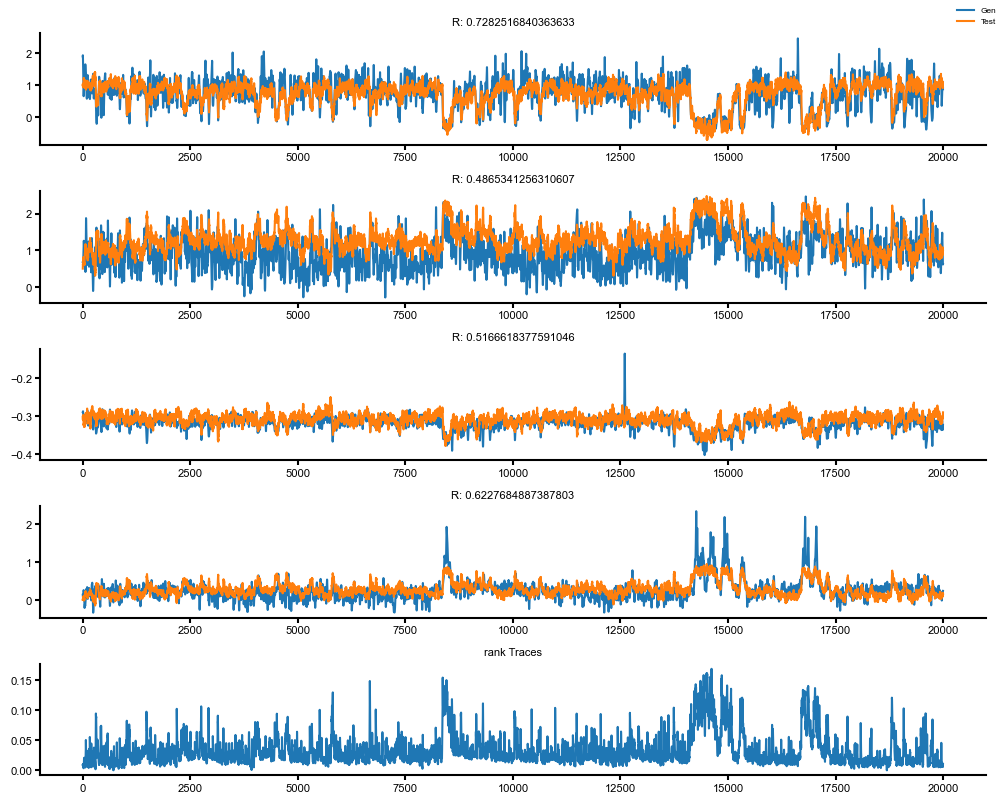

In [289]:
neurons = [172, 50, 15, 167]
plot_traces(neurons, trajs['rank'], spike_counts_val, neuromod_val, 'rank')

<Axes: >

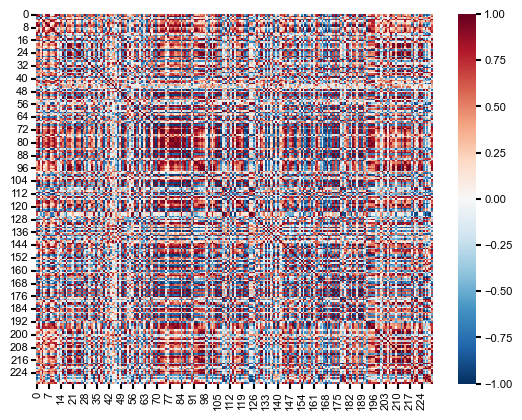

In [290]:
import seaborn as sns

corr_none = calculate_correlation(trajs['None'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
sns.heatmap(corr_none, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

<Axes: >

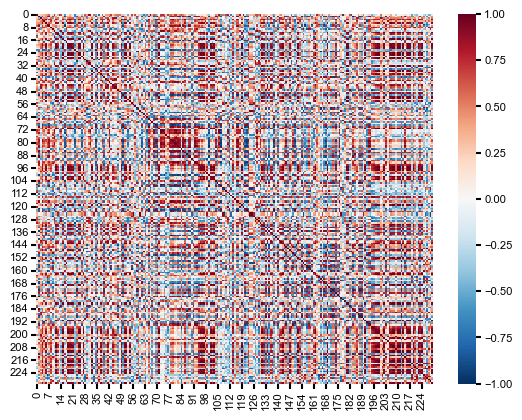

In [291]:
# compute and plot cross-correlation of all neurons in additive model
corr_add = calculate_correlation(trajs['additive'].detach().T.numpy())
corr_test = calculate_correlation(spike_counts_val.T)
sns.heatmap(corr_add, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

<Axes: >

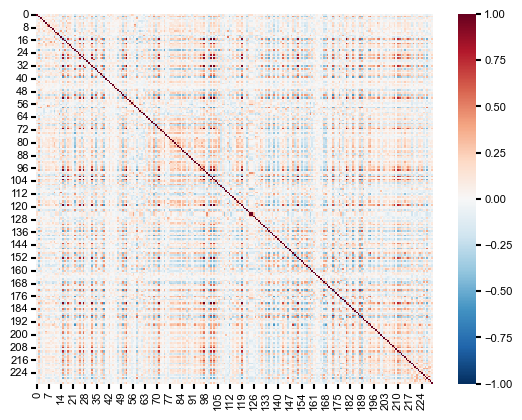

In [292]:
sns.heatmap(corr_test, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [293]:
r = pearsonr(corr_none.flatten(), corr_test.flatten())
mse_none = ((corr_none.flatten() - corr_test.flatten()) ** 2).sum() / corr_none.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.6820330195664106, pvalue=0.0) 0.2494556264773206


In [294]:
r = pearsonr(corr_add.flatten(), corr_test.flatten())
mse_add_1= ((corr_add.flatten() - corr_test.flatten()) ** 2).sum() / corr_add.flatten().shape[0] 
print(r, mse_add_1)

PearsonRResult(statistic=0.6923771707940645, pvalue=0.0) 0.17363335817452


<Axes: >

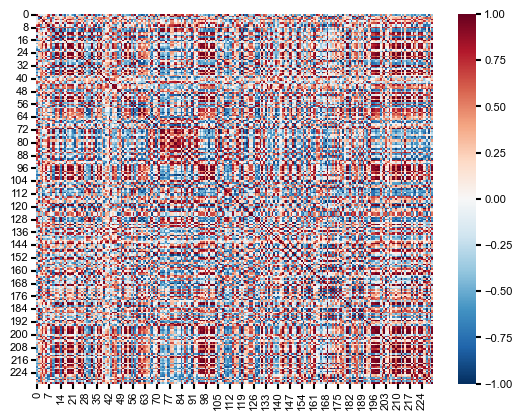

In [295]:
corr_post = calculate_correlation(trajs['postsynaptic'].detach().T.numpy())
sns.heatmap(corr_post, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [296]:
r = pearsonr(corr_post.flatten(), corr_test.flatten())
mse_post = ((corr_post.flatten() - corr_test.flatten()) ** 2).sum() / corr_post.flatten().shape[0] 
print(r, mse_post)

PearsonRResult(statistic=0.5742946283865934, pvalue=0.0) 0.23352545703859673


<Axes: >

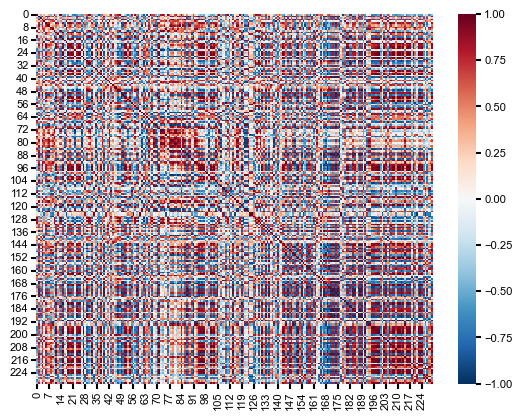

In [297]:
corr_pre = calculate_correlation(trajs['presynaptic'].detach().T.numpy())
sns.heatmap(corr_pre, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [298]:
r = pearsonr(corr_pre.flatten(), corr_test.flatten())
mse_none = ((corr_pre.flatten() - corr_test.flatten()) ** 2).sum() / corr_pre.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.6629890686410203, pvalue=0.0) 0.24509405443636043


<Axes: >

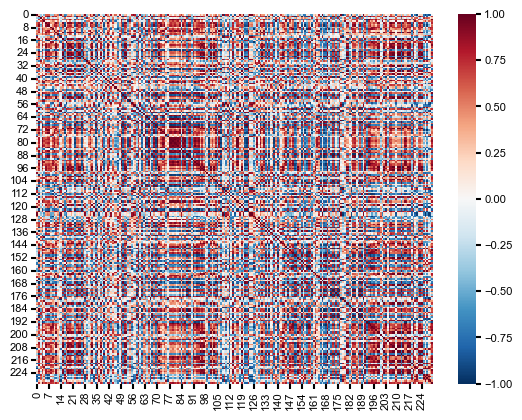

In [299]:
corr_rank = calculate_correlation(trajs['rank'].detach().T.numpy())
sns.heatmap(corr_rank, annot=False, cmap='RdBu_r', center=0, cbar=True, vmin=-1, vmax=1)

In [300]:
r = pearsonr(corr_rank.flatten(), corr_test.flatten())
mse_none = ((corr_rank.flatten() - corr_test.flatten()) ** 2).sum() / corr_rank.flatten().shape[0] 
print(r, mse_none)

PearsonRResult(statistic=0.6975946859331885, pvalue=0.0) 0.2334378493992885


### Compute KL-divergence scores

In [187]:
kl_div_add = compute_KL_divergence(trajs[list(trajs.keys())[0]].unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
kl_div_pre = compute_KL_divergence(trajs[list(trajs.keys())[2]].unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
kl_div_rank = compute_KL_divergence(trajs[list(trajs.keys())[3]].unsqueeze(0), torch.from_numpy(spike_counts_val).to(torch.float32).unsqueeze(0))
kl_div_add, kl_div_pre, kl_div_rank

KeyboardInterrupt: 

In [301]:
psh_add = power_spectrum_helling(trajs['additive'].unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000) 
psh_pre = power_spectrum_helling(trajs['presynaptic'].unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000) 
psh_rank = power_spectrum_helling(trajs['rank'].unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000)
psh_post = power_spectrum_helling(trajs['postsynaptic'].unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000)
psh_none = power_spectrum_helling(trajs['None'].unsqueeze(0).detach().numpy(), np.expand_dims(spike_counts_val, 0), smoothing=1, freq_cutoff=10000)



In [79]:
kl_div_add_1, kl_div_add_2, kl_div_none

(0.7946274280548096, 1.4032838344573975, 0.9649012088775635)

In [302]:
psh_add, psh_pre, psh_rank, psh_post, psh_none

(0.10904717040751494,
 0.1083180858244815,
 0.10729651358962605,
 0.11676348984017254,
 0.11664902980513343)

In [303]:
mr_add = mean_rate(trajs['additive'].detach().numpy(), spike_counts_val)
mr_pre = mean_rate(trajs['presynaptic'].detach().numpy(), spike_counts_val)
mr_rank = mean_rate(trajs['rank'].detach().numpy(), spike_counts_val)
mr_post = mean_rate(trajs['postsynaptic'].detach().numpy(), spike_counts_val)
mr_none = mean_rate(trajs['None'].detach().numpy(), spike_counts_val)


In [304]:
mr_add, mr_pre, mr_rank, mr_post, mr_none

(173.18162348303372,
 162.4649219651901,
 156.07988795618698,
 292.5253136826935,
 156.44495113085947)

### Compare the autocorrelograms

In [273]:
from scipy.special import rel_entr
def kl_divergence(p, q):
    """
    Compute the Kullback-Leibler (KL) divergence between two autocorrelograms.
    
    Parameters:
    p (numpy array): First autocorrelogram (distribution)
    q (numpy array): Second autocorrelogram (distribution)
    
    Returns:
    float: KL divergence
    """
    # Normalize to form probability distributions
    p = p / np.sum(p)
    q = q / np.sum(q)

    # Avoid log(0) by replacing zeros with a small value
    eps = 1e-10
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)

    # Compute KL divergence
    kl_div = np.sum(rel_entr(p, q))
    return kl_div

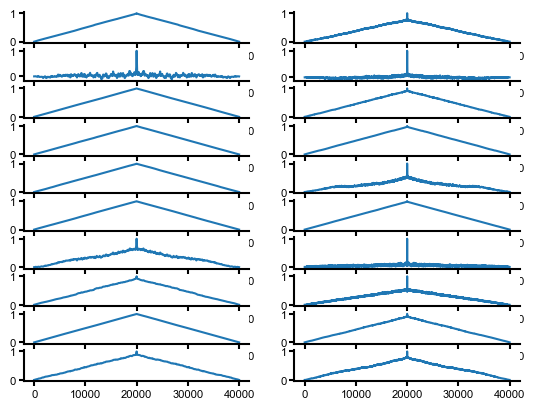

In [305]:
from scipy.special import kl_div
fig, ax = plt.subplots(10, 2)
autocorr_kl_divs = []
for i in range(spike_counts.shape[0]):
    cross_corr_gen = np.correlate(trajs['None'][i].detach(), trajs['None'][i].detach(), mode='full')
    cross_corr_gen /= cross_corr_gen.max()
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')
    cross_corr_test /= cross_corr_test.max()
    kl_divg = kl_divergence(cross_corr_gen, cross_corr_test)
    autocorr_kl_divs.append(kl_divg)
    if i < 10:
        ax[i, 0].plot(cross_corr_gen)
        ax[i, 1].plot(cross_corr_test) 

In [306]:
np.array(autocorr_kl_divs).mean(), np.array(autocorr_kl_divs).std()

(14.866515356866909, 211.16606291027023)

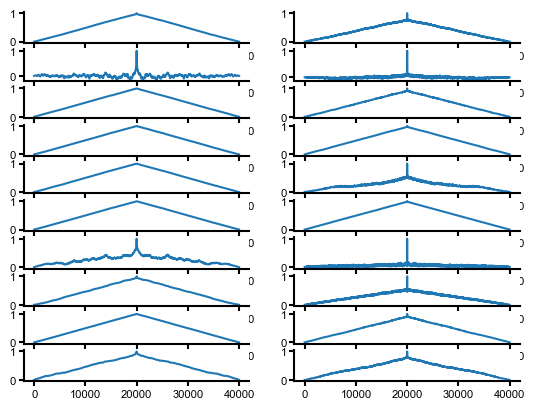

In [307]:
from scipy.special import kl_div
fig, ax = plt.subplots(10, 2)
autocorr_kl_divs = []
for i in range(spike_counts.shape[0]):
    cross_corr_gen = np.correlate(trajs['additive'][i].detach(), trajs['additive'][i].detach(), mode='full')
    cross_corr_gen /= cross_corr_gen.max()
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')
    cross_corr_test /= cross_corr_test.max()
    kl_divg = kl_divergence(cross_corr_gen, cross_corr_test)
    autocorr_kl_divs.append(kl_divg)
    if i < 10:
        ax[i, 0].plot(cross_corr_gen)
        ax[i, 1].plot(cross_corr_test) 

In [308]:
np.array(autocorr_kl_divs).mean(), np.array(autocorr_kl_divs).std()

(1.7252430323980141, 11.494029036462814)

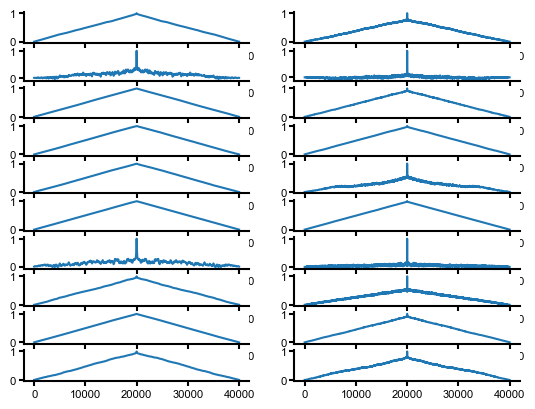

In [309]:
from scipy.special import kl_div
fig, ax = plt.subplots(10, 2)
autocorr_kl_divs = []
for i in range(spike_counts.shape[0]):
    cross_corr_gen = np.correlate(trajs['postsynaptic'][i].detach(), trajs['postsynaptic'][i].detach(), mode='full')
    cross_corr_gen /= cross_corr_gen.max()
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')
    cross_corr_test /= cross_corr_test.max()
    kl_divg = kl_divergence(cross_corr_gen, cross_corr_test)
    autocorr_kl_divs.append(kl_divg)
    if i < 10:
        ax[i, 0].plot(cross_corr_gen)
        ax[i, 1].plot(cross_corr_test) 

In [310]:
np.array(autocorr_kl_divs).mean(), np.array(autocorr_kl_divs).std()

(5.296173891086492, 60.62620695163659)

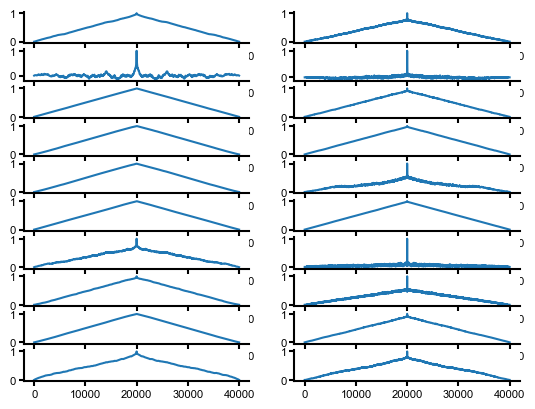

In [311]:
fig, ax = plt.subplots(10, 2)
autocorr_kl_divs = []
for i in range(spike_counts.shape[0]):
    cross_corr_gen = np.correlate(trajs['presynaptic'][i].detach(), trajs['presynaptic'][i].detach(), mode='full')
    cross_corr_gen /= cross_corr_gen.max()
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')
    cross_corr_test /= cross_corr_test.max()
    kl_divg = kl_divergence(cross_corr_gen, cross_corr_test)
    autocorr_kl_divs.append(kl_divg)
    if i < 10:
        ax[i, 0].plot(cross_corr_gen)
        ax[i, 1].plot(cross_corr_test) 

In [312]:
np.array(autocorr_kl_divs).mean(), np.array(autocorr_kl_divs).std()

(3.6330476592718637, 35.14405993216089)

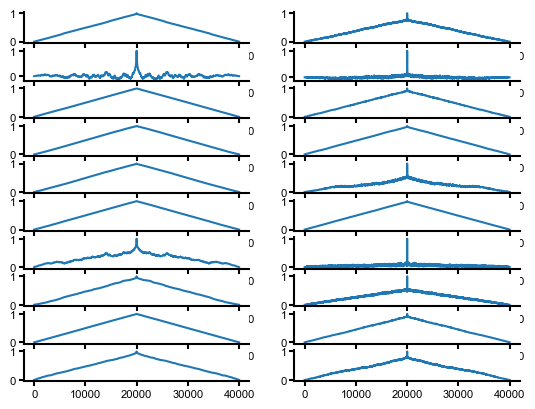

In [315]:
fig, ax = plt.subplots(10, 2)
autocorr_kl_divs = []
for i in range(spike_counts.shape[0]):
    cross_corr_gen = np.correlate(trajs['rank'][i].detach(), trajs['rank'][i].detach(), mode='full')
    cross_corr_gen /= cross_corr_gen.max()
    cross_corr_test = np.correlate(spike_counts_val[i], spike_counts_val[i], mode='full')
    cross_corr_test /= cross_corr_test.max()
    kl_divg = kl_divergence(cross_corr_gen, cross_corr_test)
    autocorr_kl_divs.append(kl_divg)
    if i < 10:
        ax[i, 0].plot(cross_corr_gen)
        ax[i, 1].plot(cross_corr_test) 

In [316]:
np.array(autocorr_kl_divs).mean(), np.array(autocorr_kl_divs).std()

(68.84342521306569, 1026.5872641634394)

In [321]:
from sklearn.metrics import r2_score
# compute R for all neurons

prs_add, prs_pre, prs_rank = [], [], []
r2s_add, r2s_pre, r2s_rank = [], [], []

nm_neurons = torch.argsort(models[list(models.keys())[1]].rnn.transition.A[:, 0].abs(), descending=True)
eval_count = 20

for i in range(len(nm_neurons)):
    pr_add = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['additive'][nm_neurons[i]].flatten().detach())[0]
    pr_pre = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['presynaptic'][nm_neurons[i]].flatten().detach())[0]
    pr_rank = pearsonr(spike_counts_val[nm_neurons[i]].flatten(), trajs['rank'][nm_neurons[i]].flatten().detach())[0]
    
    # r2_add = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[0]][nm_neurons[i]].flatten().detach())[0]
    # r2_pre = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[2]][nm_neurons[i]].flatten().detach())[0]
    # r2_rank = r2_score(spike_counts_val[nm_neurons[i]].flatten(), trajs[list(trajs.keys())[3]][nm_neurons[i]].flatten().detach())[0]
    
    prs_add.append(pr_add)
    prs_pre.append(pr_pre)
    prs_rank.append(pr_rank)

    # r2s_add.append(r2_add)
    # r2s_pre.append(r2_pre)
    # r2s_rank.append(r2_rank)

prs_add, prs_pre, prs_rank = np.array(prs_add), np.array(prs_pre), np.array(prs_rank)
print(prs_add[:eval_count].mean(), prs_add[:eval_count].std())
print(prs_pre[:eval_count].mean(), prs_pre[:eval_count].std())
print(prs_rank[:eval_count].mean(), prs_rank[:eval_count].std())


0.39283742996811083 0.1852853259229869
0.3722092996395169 0.211429271875454
0.37994665859431265 0.16312194216125403


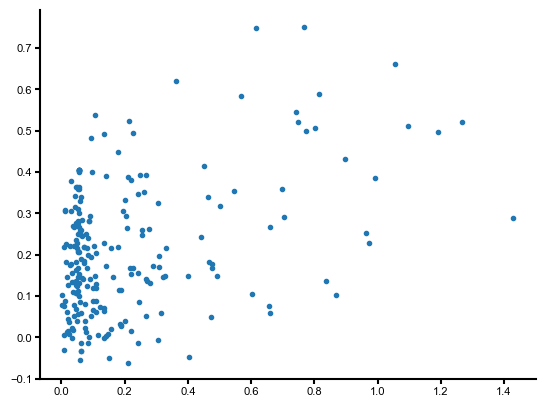

In [212]:
plt.scatter(models[list(trajs.keys())[0]].rnn.transition.A[nm_neurons].abs().detach(), prs_add)

### Compare eigenspectrums

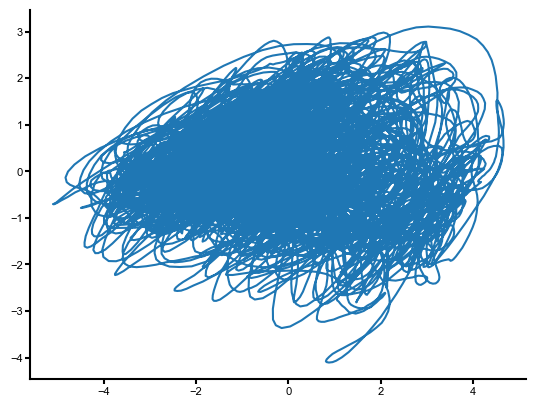

In [332]:
from sklearn.decomposition import PCA
pca_test = PCA(n_components=10) 
projected_activity = pca_test.fit_transform(spike_counts_val.T)
plt.plot(projected_activity[:, 0], projected_activity[:, 1])

2.34939033084294

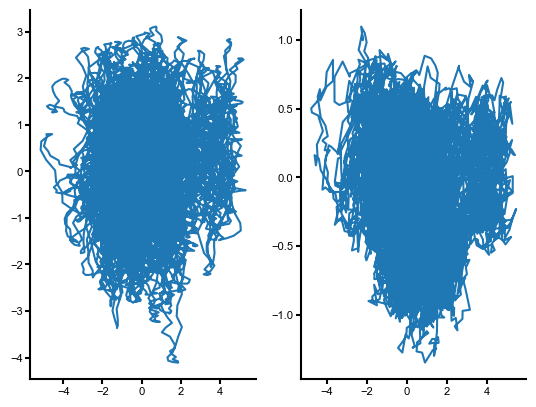

In [333]:
pca_none = PCA(n_components=10)
fig, ax = plt.subplots(1, 2)
projected_activity_self = pca_none.fit_transform(trajs['None'].detach().T)
projected_activity_test = pca_test.transform(trajs['None'].detach().T)
ax[0].plot(projected_activity_self[:, 0], projected_activity[:, 1])
ax[1].plot(projected_activity_test[:, 0], projected_activity_test[:, 1])
# compute MSE on PC space of test activity
np.sqrt(((projected_activity[:,:2] - projected_activity_test[:,:2])**2).sum(axis=1)).mean()

1.7114223959567847

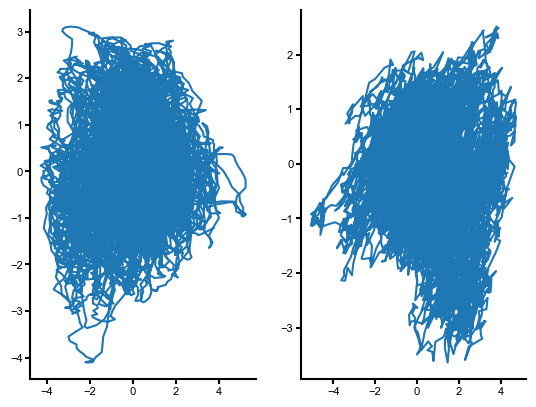

In [334]:
pca_add = PCA(n_components=10)
fig, ax = plt.subplots(1, 2)
projected_activity_self = pca_add.fit_transform(trajs['additive'].detach().T)
projected_activity_test = pca_test.transform(trajs['additive'].detach().T)
ax[0].plot(projected_activity_self[:, 0], projected_activity[:, 1])
ax[1].plot(projected_activity_test[:, 0], projected_activity_test[:, 1])
# compute MSE on PC space of test activity
np.sqrt(((projected_activity[:,:2] - projected_activity_test[:,:2])**2).sum(axis=1)).mean()

1.7210266777853296

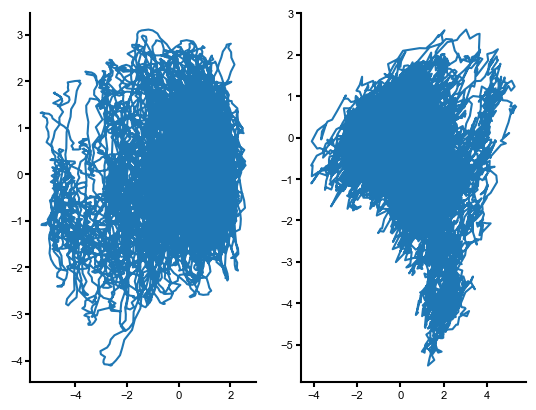

In [335]:
pca_pre = PCA(n_components=10)
fig, ax = plt.subplots(1, 2)
projected_activity_self = pca_pre.fit_transform(trajs['presynaptic'].detach().T)
projected_activity_test = pca_test.transform(trajs['presynaptic'].detach().T)
ax[0].plot(projected_activity_self[:, 0], projected_activity[:, 1])
ax[1].plot(projected_activity_test[:, 0], projected_activity_test[:, 1])
# compute MSE on PC space of test activity
np.sqrt(((projected_activity[:,:2] - projected_activity_test[:,:2])**2).sum(axis=1)).mean()

1.6635067063317988

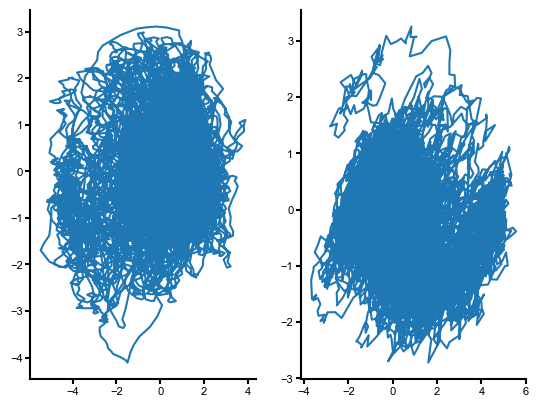

In [336]:
pca_rank = PCA(n_components=10)
fig, ax = plt.subplots(1, 2)
projected_activity_self = pca_rank.fit_transform(trajs['rank'].detach().T)
projected_activity_test = pca_test.transform(trajs['rank'].detach().T)
ax[0].plot(projected_activity_self[:, 0], projected_activity[:, 1])
ax[1].plot(projected_activity_test[:, 0], projected_activity_test[:, 1])
# compute MSE on PC space of test activity
np.sqrt(((projected_activity[:,:2] - projected_activity_test[:,:2])**2).sum(axis=1)).mean()

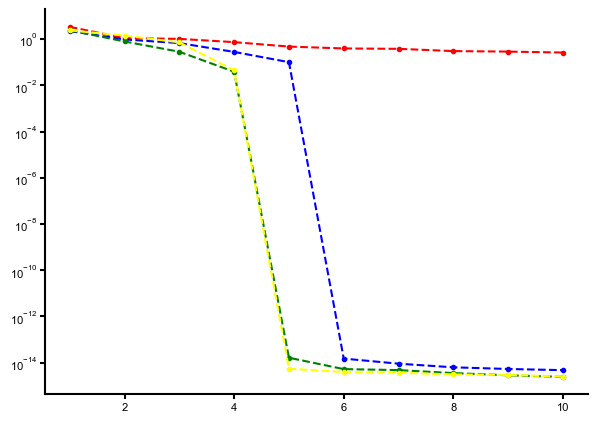

In [337]:
eigenvalues_test = pca_test.explained_variance_  # Variance explained by each PC
eigenvalues_add = pca_add.explained_variance_  # Variance explained by each PC
eigenvalues_rank = pca_rank.explained_variance_
eigenvalues_pre = pca_pre.explained_variance_

# Plot eigenspectrum
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(eigenvalues_test) + 1), eigenvalues_test, marker="o", linestyle="--", color="r")
plt.plot(np.arange(1, len(eigenvalues_add) + 1), eigenvalues_add, marker="o", linestyle="--", color="b")
plt.plot(np.arange(1, len(eigenvalues_rank) + 1), eigenvalues_rank, marker="o", linestyle="--", color="g")
plt.plot(np.arange(1, len(eigenvalues_pre) + 1), eigenvalues_pre, marker="o", linestyle="--", color="yellow")


plt.yscale("log")  # Log scale to highlight differences
